### Mnist分类任务：

- 网络基本构建与训练方法，常用函数解析

- torch.nn.functional模块

- nn.Module模块


### 读取Mnist数据集
- 会自动进行下载

### 学习方法：
- 1.边用边学，Torch只是一个工具，真正用，查的过程才是学习的过程
- 2.直接上案例就行，先来跑，遇到啥解决啥就ok

In [3]:
%matplotlib inline

In [4]:
from pathlib import Path
import requests

DATA_PATH = Path("data")
PATH = DATA_PATH / "mnist"

PATH.mkdir(parents=True, exist_ok=True)

URL = "http://deeplearning.net/data/mnist/"
FILENAME = "mnist.pkl.gz"

if not (PATH / FILENAME).exists():
        content = requests.get(URL + FILENAME).content
        (PATH / FILENAME).open("wb").write(content)

In [5]:
import pickle
import gzip

with gzip.open((PATH / FILENAME).as_posix(), "rb") as f:
        ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")

In [11]:
y_train[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=int64)

784是mnist数据集每个样本的像素点个数

(50000, 784)


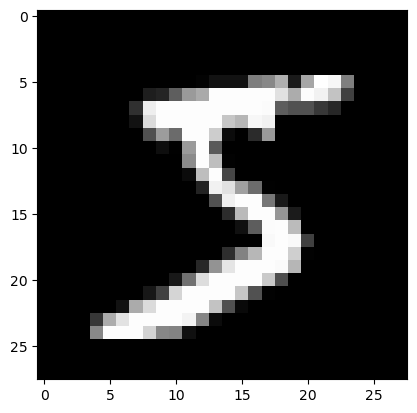

In [10]:
from matplotlib import pyplot
import numpy as np

pyplot.imshow(x_train[0].reshape((28, 28)), cmap="gray")
print(x_train.shape)

<img src="./img/4.png" alt="FAO" width="790">

<img src="./img/5.png" alt="FAO" width="790">

注意数据需转换成tensor才能参与后续建模训练


In [12]:
import torch

x_train, y_train, x_valid, y_valid = map(
    torch.tensor, (x_train, y_train, x_valid, y_valid)
)
n, c = x_train.shape
x_train, x_train.shape, y_train.min(), y_train.max()
print(x_train, y_train)
print(x_train.shape)
print(y_train.min(), y_train.max())

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([5, 0, 4,  ..., 8, 4, 8])
torch.Size([50000, 784])
tensor(0) tensor(9)


### torch.nn.functional 很多层和函数在这里都会见到

torch.nn.functional中有很多功能，后续会常用的。那什么时候使用nn.Module，什么时候使用nn.functional呢？一般情况下，如果模型有可学习的参数，最好用nn.Module，其他情况nn.functional相对更简单一些

In [ ]:
import torch.nn.functional as F

loss_func = F.cross_entropy

def model(xb):
    return xb.mm(weights) + bias#xw+b

In [14]:
bs = 64
xb = x_train[0:bs]  # a mini-batch from x
yb = y_train[0:bs]
weights = torch.randn([784, 10], dtype = torch.float,  requires_grad = True) 
bs = 64
bias = torch.zeros(10, requires_grad=True)

print(loss_func(model(xb), yb))

tensor(18.6181, grad_fn=<NllLossBackward0>)


### 创建一个model来更简化代码

- 必须继承nn.Module且在其构造函数中需调用nn.Module的构造函数
- 无需写反向传播函数，nn.Module能够利用autograd自动实现反向传播
- Module中的可学习参数可以通过named_parameters()或者parameters()返回迭代器

In [ ]:
from torch import nn

class Mnist_NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(784, 128)
        self.hidden2 = nn.Linear(128, 256)
        self.out  = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):            #定义好前向传播 x是batch中的数据
        x = F.relu(self.hidden1(x))
        x = self.dropout(x)          #每一个全连接层都加上一个dropout
        x = F.relu(self.hidden2(x))
        x = self.dropout(x)
        x = self.out(x)
        return x
        

In [19]:
net = Mnist_NN()
print(net)


Mnist_NN(
  (hidden1): Linear(in_features=784, out_features=128, bias=True)
  (hidden2): Linear(in_features=128, out_features=256, bias=True)
  (out): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


可以打印我们定义好名字里的权重和偏置项

In [20]:
for name, parameter in net.named_parameters():
    print(name, parameter,parameter.size())

hidden1.weight Parameter containing:
tensor([[-0.0325, -0.0038,  0.0291,  ...,  0.0015, -0.0238,  0.0181],
        [-0.0221, -0.0341, -0.0085,  ...,  0.0045,  0.0041, -0.0257],
        [-0.0229, -0.0014, -0.0024,  ..., -0.0288, -0.0084,  0.0277],
        ...,
        [ 0.0078, -0.0172,  0.0296,  ...,  0.0098, -0.0142,  0.0080],
        [ 0.0055, -0.0283,  0.0336,  ..., -0.0348, -0.0171,  0.0291],
        [-0.0320,  0.0207, -0.0055,  ..., -0.0209,  0.0190,  0.0107]],
       requires_grad=True) torch.Size([128, 784])
hidden1.bias Parameter containing:
tensor([-0.0338, -0.0327, -0.0174,  0.0262, -0.0266, -0.0293,  0.0084, -0.0074,
        -0.0193,  0.0197,  0.0229, -0.0073, -0.0196, -0.0011, -0.0129, -0.0226,
         0.0277, -0.0258,  0.0032,  0.0173, -0.0271,  0.0342, -0.0222, -0.0283,
        -0.0107,  0.0235, -0.0202,  0.0076, -0.0104,  0.0219, -0.0302,  0.0066,
        -0.0228,  0.0142,  0.0024, -0.0242,  0.0014, -0.0080, -0.0306, -0.0123,
        -0.0039,  0.0059, -0.0012,  0.0219, 

### 使用TensorDataset和DataLoader来简化

In [21]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

train_ds = TensorDataset(x_train, y_train)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True)

valid_ds = TensorDataset(x_valid, y_valid)
valid_dl = DataLoader(valid_ds, batch_size=bs * 2)

In [22]:
def get_data(train_ds, valid_ds, bs):
    return (
        DataLoader(train_ds, batch_size=bs, shuffle=True),
        DataLoader(valid_ds, batch_size=bs * 2),
    )

- 一般在训练模型时加上model.train()，这样会正常使用Batch Normalization和 Dropout
- 测试的时候一般选择model.eval()，这样就不会使用Batch Normalization和 Dropout

In [ ]:
import numpy as np

def fit(steps, model, loss_func, opt, train_dl, valid_dl):
    for step in range(steps):
        model.train()#会更新每一层的w和偏置b
        for xb, yb in train_dl:
            loss_batch(model, loss_func, xb, yb, opt)

        model.eval()#验证过程 不会更新
        with torch.no_grad():
            losses, nums = zip(#一个loss对应一个nums
                *[loss_batch(model, loss_func, xb, yb) for xb, yb in valid_dl]
            )
        val_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)#总损失/数量=平均损失
        print('当前step:'+str(step), '验证集损失：'+str(val_loss))

In [29]:
# 1. 先准备好模型和优化器 (必须先有这两个参数)
model, opt = get_model()

# 2. 真正开始跑！(调用你刚才定义的 fit)
# 这里的 5 是跑 5 轮，你可以改成 10 或 20
fit(5, model, loss_func, opt, train_dl, valid_dl)

当前step:0 验证集损失：2.2809090850830076
当前step:1 验证集损失：2.25027811088562
当前step:2 验证集损失：2.2027821662902833
当前step:3 验证集损失：2.1245586490631103
当前step:4 验证集损失：1.9965420055389405


zip的用法

In [26]:
a = [1,2,3]
b = [4,5,6]
zipped = zip(a,b)
print(list(zipped))
a2, b2 = zip(*zip(a,b))
print(a2)
print(b2)

[(1, 4), (2, 5), (3, 6)]
(1, 2, 3)
(4, 5, 6)


In [27]:
from torch import optim
def get_model():
    model = Mnist_NN()
    return model, optim.SGD(model.parameters(), lr=0.001) #adam优化器 把SGD改成Adam

In [28]:
def loss_batch(model, loss_func, xb, yb, opt=None):
    loss = loss_func(model(xb), yb)

    if opt is not None:
        loss.backward()
        opt.step()
        opt.zero_grad()#更新梯度 梯度必须清零 不能把这一层的梯度带到下一层

    return loss.item(), len(xb)

### 三行搞定！

In [30]:
train_dl, valid_dl = get_data(train_ds, valid_ds, bs)
model, opt = get_model()
fit(25, model, loss_func, opt, train_dl, valid_dl)

当前step:0 验证集损失：2.2779212200164793
当前step:1 验证集损失：2.2427568336486816
当前step:2 验证集损失：2.1879220973968505
当前step:3 验证集损失：2.0998380794525144
当前step:4 验证集损失：1.9631558731079102
当前step:5 验证集损失：1.7660979022979737
当前step:6 验证集损失：1.517039441871643
当前step:7 验证集损失：1.2614568433761597
当前step:8 验证集损失：1.0485547872543335
当前step:9 验证集损失：0.8904793952941894
当前step:10 验证集损失：0.776172509765625
当前step:11 验证集损失：0.6923806889533997
当前step:12 验证集损失：0.6292443974494935
当前step:13 验证集损失：0.5809320019721985
当前step:14 验证集损失：0.5430351199626923
当前step:15 验证集损失：0.5116432373523712
当前step:16 验证集损失：0.4862869896888733
当前step:17 验证集损失：0.4658512710094452
当前step:18 验证集损失：0.44796148319244383
当前step:19 验证集损失：0.432932000541687
当前step:20 验证集损失：0.4199365017414093
当前step:21 验证集损失：0.40798774313926695
当前step:22 验证集损失：0.3979632670164108
当前step:23 验证集损失：0.38911549460887906
当前step:24 验证集损失：0.3810059963941574


In [ ]:
correct = 0
total = 0
for xb, yb in valid_dl:
    outputs = model(xb)
    _, predicted = torch.max(outputs.data, 1)#最大的值和索引(位置)
    total += yb.size(0)#64个
    correct += (predicted == yb).sum() .item()

print('Accuracy of the network on the 10000 test images: %d %%' %(
    100 * correct / total
))

Accuracy of the network on the 10000 test images: 89 %


In [ ]:
correct = 0
total = 0
for xb, yb in valid_dl:
    outputs = model(xb)#每个样本属于各个类别的概率值
    _, predicted = torch.max(outputs.data, 1)
    print(_)
    total += yb.size(0)
    print(predicted == yb)#打印的是true false 预测对了还是错了
    print(predicted)
    print(yb.size(0))#一共128个
    print((predicted == yb).sum())#预测对了113个
    break

tensor([ 5.6840,  4.6031,  5.7581,  5.4258,  8.0582,  2.5716,  5.3719,  4.6451,
         3.8102,  2.6511,  4.2598,  7.1571,  7.4443,  4.7661,  6.2516,  5.7731,
         4.5564,  4.4925,  8.6506,  5.5778,  5.0457,  5.2651,  5.9349,  4.8830,
         5.4144,  3.5677,  5.7272,  5.7882,  8.5410,  5.3214,  6.5883,  4.2116,
         6.4988,  5.4210,  8.1174,  3.5561, 13.6055,  3.4910,  5.9388,  7.2621,
         6.1164,  4.0731,  6.7188,  5.7258,  3.1542,  6.7339,  4.5014,  5.3605,
         4.0386,  1.7828,  6.4743,  4.7192,  5.6424,  4.5874,  4.8036,  6.0030,
         4.3458,  7.9469,  7.0431,  4.6774,  4.3208, 11.5648,  6.7836,  7.1282,
         7.5992,  7.2908,  9.5679,  3.2268,  5.0086,  6.3647,  8.8012,  2.7388,
        10.0665,  6.9680,  2.3544,  4.9727,  5.5853,  6.0595,  4.7421,  5.0612,
         4.5483,  9.1573,  4.4658,  6.8593,  4.2454,  5.5718,  7.1441,  4.3992,
         3.8505,  7.0710,  2.4046,  3.2738,  8.8437,  9.7855,  4.5163, 10.4629,
        10.0835,  5.5003,  8.7167,  5.64

In [21]:
import torch
import torch.nn.functional as F  # 引入这个为了把分数变成概率

# 1. 还是拿第 8 张图
image, label = valid_ds[8]

# 2. 变形：看看变形前后的区别
print(f"原始图片形状: {image.shape}") 
image_batch = image.unsqueeze(0)
print(f"加了袋子后的形状: {image_batch.shape}")
print("-" * 30)

# 3. 进模型预测 (获取原始打分 Logits)
model.eval()
with torch.no_grad():
    raw_scores = model(image_batch) # 这就是你要看的那个列表！

print("【模型的原始打分 (Logits)】:")
print(raw_scores)
print("\n注意看：这里面最大的那个数，对应的就是模型选的答案。")
print("-" * 30)

# 4. 翻译成概率 (Softmax)
# 这一步是为了让人类更好看懂，把分数变成 0~1 之间的概率
probabilities = F.softmax(raw_scores, dim=1)

print("【翻译成概率 (Probabilities)】:")
# 我们用 enumerate 把 0-9 每个数字的概率打印出来
for i, prob in enumerate(probabilities[0]):
    # {prob:.4f} 是保留4位小数的意思
    print(f"数字 {i} 的概率: {prob.item():.4f}")

print("-" * 30)
print(f"最终结果: {torch.argmax(raw_scores).item()} (标准答案是 {label})")

原始图片形状: torch.Size([784])
加了袋子后的形状: torch.Size([1, 784])
------------------------------
【模型的原始打分 (Logits)】:
tensor([[-2.6513,  0.2799, -0.0172,  1.2245, -1.1189,  1.6167, -2.3500, -0.4652,
          4.1901,  1.4131]])

注意看：这里面最大的那个数，对应的就是模型选的答案。
------------------------------
【翻译成概率 (Probabilities)】:
数字 0 的概率: 0.0009
数字 1 的概率: 0.0161
数字 2 的概率: 0.0120
数字 3 的概率: 0.0415
数字 4 的概率: 0.0040
数字 5 的概率: 0.0614
数字 6 的概率: 0.0012
数字 7 的概率: 0.0077
数字 8 的概率: 0.8052
数字 9 的概率: 0.0501
------------------------------
最终结果: 8 (标准答案是 8)
